In [1]:
import numpy as np
import matplotlib.pyplot as plt

import constants
import vertical_profile as vp

Sigmoid quantum wells

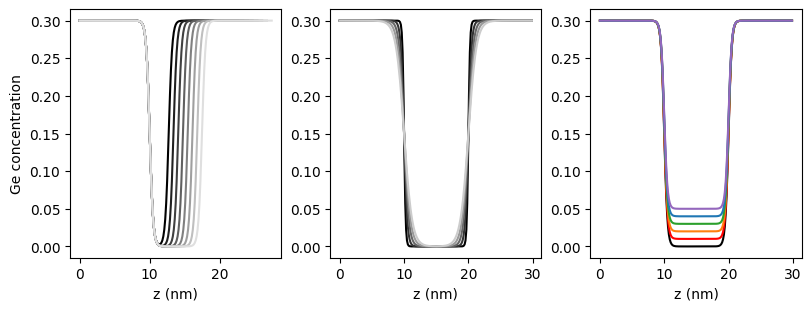

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(8, 3), layout='constrained')

# Vary well width
well_width_ml_arr = np.array(range(20, 60, 5))
well_width_nm_arr = well_width_ml_arr * constants.SI_LATTICE_CONSTANT / 4 * 1e9

for i, well_width_nm in enumerate(well_width_nm_arr):
    prof = vp.VerticalProfile(
        interface_type = 'sigmoid',
        well_width_nm = well_width_nm,
    )

    ge_conc = prof.ge_concentrations
    z_arr = prof.z_arr

    col = (i/len(well_width_nm_arr), i/len(well_width_nm_arr), i/len(well_width_nm_arr))
    ax[0].plot(1e9*z_arr, ge_conc, color=col)

# Vary interface width
int_width_nm_arr = np.linspace(0.5, 2.5, 5)

for i, int_width_nm in enumerate(int_width_nm_arr):
    prof = vp.VerticalProfile(
        interface_type = 'sigmoid',
        top_interface_width_nm = int_width_nm,
        bot_interface_width_nm = int_width_nm,
    )

    ge_conc = prof.ge_concentrations
    z_arr = prof.z_arr

    col = (i/len(int_width_nm_arr), i/len(int_width_nm_arr), i/len(int_width_nm_arr))
    ax[1].plot(1e9*z_arr, ge_conc, color=col)


# Vary ge concentration in the well
well_ge_conc_arr = np.linspace(0, 0.05, 6)
color_arr = ['k', 'r', 'tab:orange', 'tab:green', 'tab:blue', 'tab:purple']


for i, well_ge_conc in enumerate(well_ge_conc_arr):
    prof = vp.VerticalProfile(
        interface_type = 'sigmoid',
        well_si_concentration = 1 - well_ge_conc,
    )

    ge_conc = prof.ge_concentrations
    z_arr = prof.z_arr

    ax[2].plot(1e9*z_arr, ge_conc, color=color_arr[i])

ax[0].set_xlabel('z (nm)')
ax[1].set_xlabel('z (nm)')
ax[2].set_xlabel('z (nm)')
ax[0].set_ylabel('Ge concentration')
plt.show()

Linear wall quantum wells

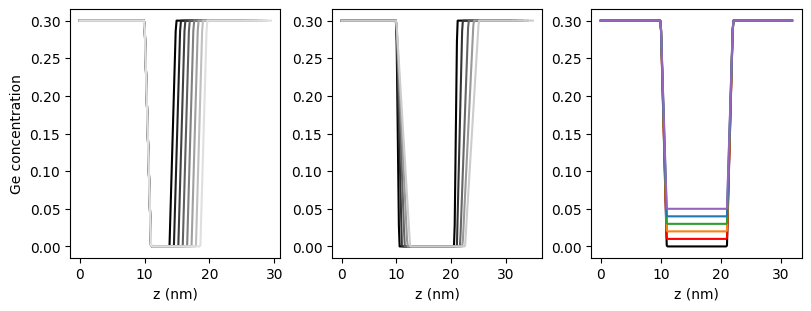

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(8, 3), layout='constrained')

# Vary well width
well_width_ml_arr = np.array(range(20, 60, 5))
well_width_nm_arr = well_width_ml_arr * constants.SI_LATTICE_CONSTANT / 4 * 1e9

for i, well_width_nm in enumerate(well_width_nm_arr):
    prof = vp.VerticalProfile(
        interface_type = 'linear-wall',
        well_width_nm = well_width_nm,
    )

    ge_conc = prof.ge_concentrations
    z_arr = prof.z_arr

    col = (i/len(well_width_nm_arr), i/len(well_width_nm_arr), i/len(well_width_nm_arr))
    ax[0].plot(1e9*z_arr, ge_conc, color=col)

# Vary interface width
int_width_nm_arr = np.linspace(0.5, 2.5, 5)

for i, int_width_nm in enumerate(int_width_nm_arr):
    prof = vp.VerticalProfile(
        interface_type = 'linear-wall',
        top_interface_width_nm = int_width_nm,
        bot_interface_width_nm = int_width_nm,
    )

    ge_conc = prof.ge_concentrations
    z_arr = prof.z_arr

    col = (i/len(int_width_nm_arr), i/len(int_width_nm_arr), i/len(int_width_nm_arr))
    ax[1].plot(1e9*z_arr, ge_conc, color=col)


# Vary ge concentration in the well
well_ge_conc_arr = np.linspace(0, 0.05, 6)
color_arr = ['k', 'r', 'tab:orange', 'tab:green', 'tab:blue', 'tab:purple']


for i, well_ge_conc in enumerate(well_ge_conc_arr):
    prof = vp.VerticalProfile(
        interface_type = 'linear-wall',
        well_si_concentration = 1 - well_ge_conc,
    )

    ge_conc = prof.ge_concentrations
    z_arr = prof.z_arr

    ax[2].plot(1e9*z_arr, ge_conc, color=color_arr[i])
    
ax[0].set_xlabel('z (nm)')
ax[1].set_xlabel('z (nm)')
ax[2].set_xlabel('z (nm)')
ax[0].set_ylabel('Ge concentration')
plt.show()

Linear versus smoothed linear interfaces

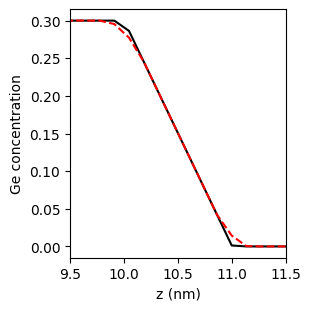

In [4]:
prof = vp.VerticalProfile(interface_type = 'linear-wall')
ge_linear = prof.ge_concentrations
z_arr = prof.z_arr

prof = vp.VerticalProfile(interface_type = 'smoothed-linear-wall')
ge_smooth_linear = prof.ge_concentrations

fig, ax = plt.subplots(figsize=(3,3), layout='constrained')
ax.plot(1e9*z_arr, ge_linear, 'k-')
ax.plot(1e9*z_arr, ge_smooth_linear, 'r--')
ax.set_xlim([9.5, 11.5])
ax.set_xlabel('z (nm)')
ax.set_ylabel('Ge concentration')
plt.show()

Wiggle well constructions

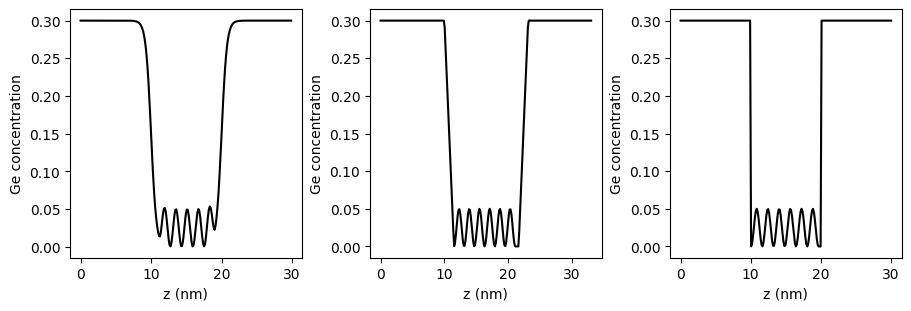

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(9,3), layout='constrained')

prof = vp.VerticalProfile(interface_type = 'sigmoid', wiggle_amplitude = 0.05, top_interface_width_nm = 1.5, bot_interface_width_nm = 1.5, well_width_nm = 10)
ge_sig = prof.ge_concentrations
z_arr = prof.z_arr

ax[0].plot(1e9*z_arr, ge_sig, 'k-')
ax[0].set_xlabel('z (nm)')
ax[0].set_ylabel('Ge concentration')

prof = vp.VerticalProfile(interface_type = 'linear-wall', wiggle_amplitude = 0.05, top_interface_width_nm = 1.5, bot_interface_width_nm = 1.5, well_width_nm = 10)
ge_lin = prof.ge_concentrations
z_arr = prof.z_arr

ax[1].plot(1e9*z_arr, ge_lin, 'k-')
ax[1].set_xlabel('z (nm)')
ax[1].set_ylabel('Ge concentration')

prof = vp.VerticalProfile(interface_type = 'sharp', wiggle_amplitude = 0.05, top_interface_width_nm = 1.5, bot_interface_width_nm = 1.5, well_width_nm = 10)
ge_sharp = prof.ge_concentrations
z_arr = prof.z_arr

ax[2].plot(1e9*z_arr, ge_sharp, 'k-')
ax[2].set_xlabel('z (nm)')
ax[2].set_ylabel('Ge concentration')

plt.show()

